In [1]:
import numpy as np
from scipy import optimize
from scipy.stats import linregress
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:

import os
import glob
from collections import defaultdict

import pandas as pd

In [4]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

def ax(x, a):
    return a*x

In [5]:
folder_with_data = '/home/md/md/PES-255_dens/Tg200-new_limits/modulus-Pdamp_100'
P = '1'
dim = 'sy'
NAME = 'PES-255'

In [16]:
#Нахожу def1.txt файлы во всех папках p_N:
collected_data = defaultdict(list)

for f in glob.glob(f'{folder_with_data}/*_*/def1.txt'):
    print(f)
    
    pressure = os.path.dirname(f).split('_')[-1]
    # pressure = f.split('\\')[1].split('_')[0]     

    df_Strain_and_Stress = pd.read_csv(
        f,
        skiprows=1,
        header=None,
        sep='\s+',
        engine='python'
    )

    df_Strain_and_Stress.columns = ['deformation', 'sx', 'sy', 'sz']

    collected_data[pressure].append(df_Strain_and_Stress)

/home/artem/LAMMPS/Tglass/PES-185-try2/modulus/p_10000/def1.txt
/home/artem/LAMMPS/Tglass/PES-185-try2/modulus/p_100/def1.txt
/home/artem/LAMMPS/Tglass/PES-185-try2/modulus/p_1000/def1.txt
/home/artem/LAMMPS/Tglass/PES-185-try2/modulus/p_1/def1.txt


In [17]:
collected_data = {k: pd.concat(df_list, axis=0) for k, df_list in collected_data.items()}

<Axes: xlabel='deformation', ylabel='sx'>

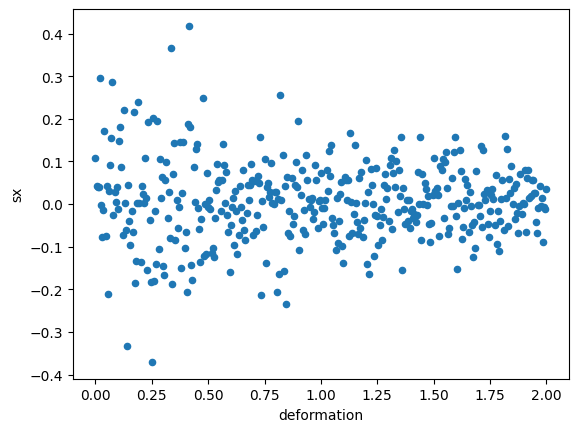

In [27]:
#Рисую график Деформация - Напряжение по всем точкам для данного давления:
collected_data[P].plot(kind='scatter', x='deformation', y=dim)

In [20]:
df = collected_data[P]

In [21]:
df

,deformation,sx,sy,sz
0,-2.207819e-16,0.108480,0.301948,0.130861
1,5.000000e-03,0.041980,0.104372,-0.176268
2,1.000000e-02,0.039747,-0.021473,0.000381
3,1.500000e-02,0.040724,0.116126,0.028267
4,2.000000e-02,0.296670,0.174774,0.010801
...,...,...,...,...
396,1.980000e+00,0.014146,0.125791,-0.017100
397,1.985000e+00,-0.088688,0.264472,-0.003111
398,1.990000e+00,-0.007450,0.145193,-0.082761
399,1.995000e+00,-0.012450,0.148528,-0.005841


In [22]:
deformation_range = (0, 0.16)
d_range = np.linspace(0, max(deformation_range) + 0.1, 50)
x = df[df['deformation'] <= max(deformation_range)]['deformation']
y = df[df['deformation'] <= max(deformation_range)][dim]

slope, pcov = curve_fit(ax, x, y)
R2 = r2_score(y, slope*x)

slope, R2


# linefit = linregress(x, y)
# intercept, slope, R2 = linefit.intercept, linefit.slope, linefit.rvalue**2
# intercept, slope, R2

(array([0.12020874]), -0.05268942378699415)

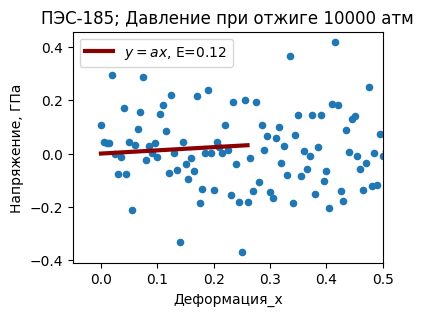

In [28]:
#Рисую график с линией тренда до 16% деформации:
df.plot.scatter(x='deformation', y=dim, figsize=(4, 3))
plt.plot(d_range, slope*d_range, 'darkred', label=f'$y={dim}$, E={slope[0]:.2f}', lw=3)
# plt.plot(d_range, intercept + slope*d_range, 'darkred', label=f'linear fit; $R^2$={R2:.3f}', lw=3)
plt.xlim(-0.05, 0.5)
plt.xlabel('Деформация %s' % dim)
plt.ylabel('Напряжение, ГПа')
plt.title('%s; Давление при отжиге %s атм' % (NAME, P))
plt.legend()
plt.savefig('%s_p_%s_%s.png' % (NAME,P,dim),bbox_inches='tight')